In [19]:
# Standar libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

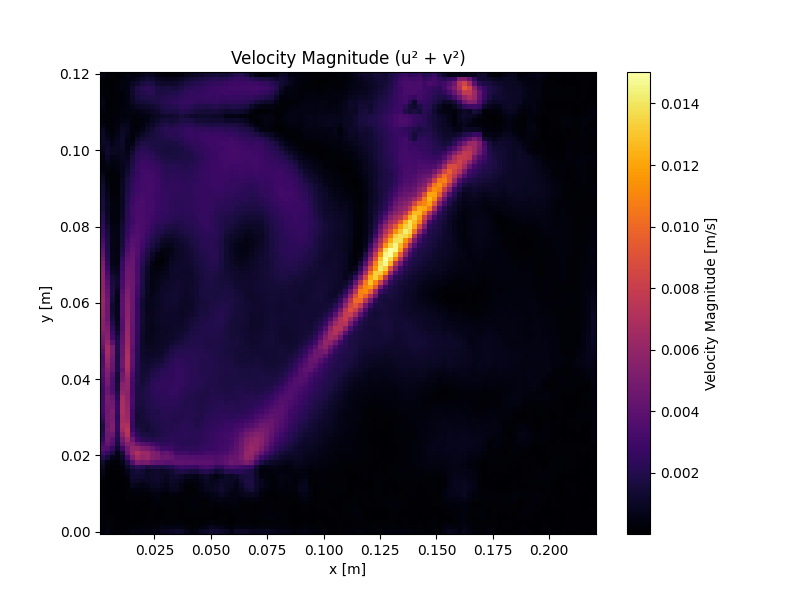

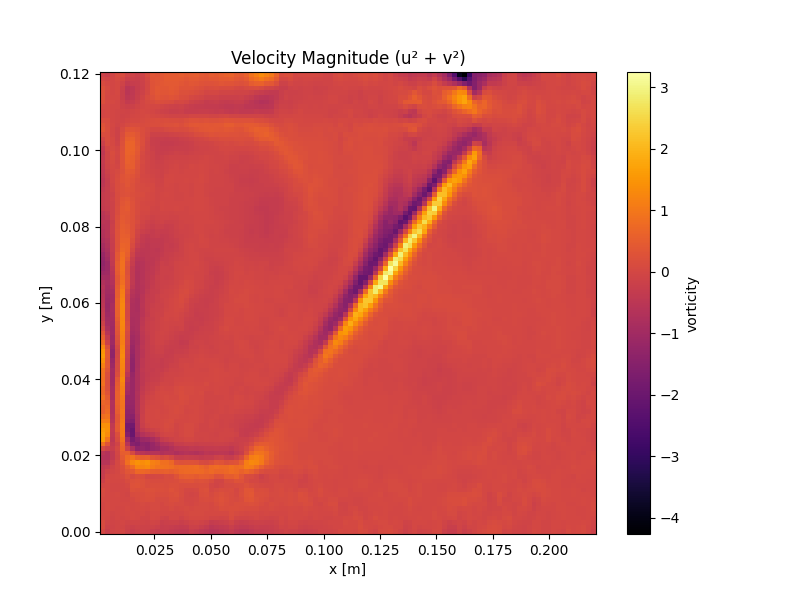

In [20]:
# Read the file, skip first 3 lines, split by ',' and store columns in vectors
filename = "./EPM_3980_results_PIVLab/PIVlab_mean.txt"

# Initialize empty lists for columns
columns = []

with open(filename, 'r') as file:
    # Skip first 3 lines
    for _ in range(3):
        next(file)
    # Read the rest of the lines
    for line in file:
        # Remove whitespace and split by ','
        values = line.strip().split(',')
        # If columns is empty, initialize lists for each column
        if not columns:
            columns = [[] for _ in range(len(values))]
        # Append each value to its respective column
        for i, value in enumerate(values):
            columns[i].append(float(value))  # or value if not float

# Now columns[0], columns[1], ... are your vectors
# Example: print first column
#print("First column:", columns[0])



# Assign columns to variables
x = np.array(columns[0])
y = np.array(columns[1])
u = np.array(columns[2])
v = np.array(columns[3])
vorticity = np.array(columns[5])
magnitude=np.array(columns[6])

y2=y.max()-y
v2=-v

# # Plot quiver map
# plt.figure(figsize=(8, 6))
# plt.quiver(x, y2, u, v2, scale=1)
# plt.xlabel('x [m]')
# plt.ylabel('y [m]')
# plt.title('PIVLab')

# Compute velocity magnitude
velocity_magnitude = np.sqrt(u**2 + v2**2)

# Plot colormesh of velocity magnitude
plt.figure(figsize=(8, 6))
# Use a grid for colormesh if possible, otherwise scatter as fallback
from scipy.interpolate import griddata

# Create grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y2.min(), y2.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate velocity magnitude onto grid
data = griddata((x, y2), magnitude, (Xi, Yi), method='linear')
datamin=data.min()
datamax=data.max()



# Plot colormesh
c = plt.pcolormesh(Xi, Yi, data, shading='auto', cmap='inferno', vmin=datamin, vmax=datamax)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Velocity Magnitude (u² + v²)')
plt.colorbar(c, label='Velocity Magnitude [m/s]')
plt.show()


plt.figure(figsize=(8, 6))
# Use a grid for colormesh if possible, otherwise scatter as fallback
from scipy.interpolate import griddata

# Create grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y2.min(), y2.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate velocity magnitude onto grid
data = griddata((x, y2), vorticity, (Xi, Yi), method='linear')
datamin=data.min()
datamax=data.max()



# Plot colormesh
c = plt.pcolormesh(Xi, Yi, data, shading='auto', cmap='inferno', vmin=datamin, vmax=datamax)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Velocity Magnitude (u² + v²)')
plt.colorbar(c, label='vorticity')
plt.show()